Sample of original data (first 5 rows):
[[1.32929189e+04 3.38819340e-13]
 [7.11447601e+05 2.03471213e-13]
 [1.57029709e+05 2.19677037e-13]
 [6.25137357e+04 2.07501932e-14]
 [2.93802794e+03 4.03619363e-13]]
Data after log transformation and robust scaling:


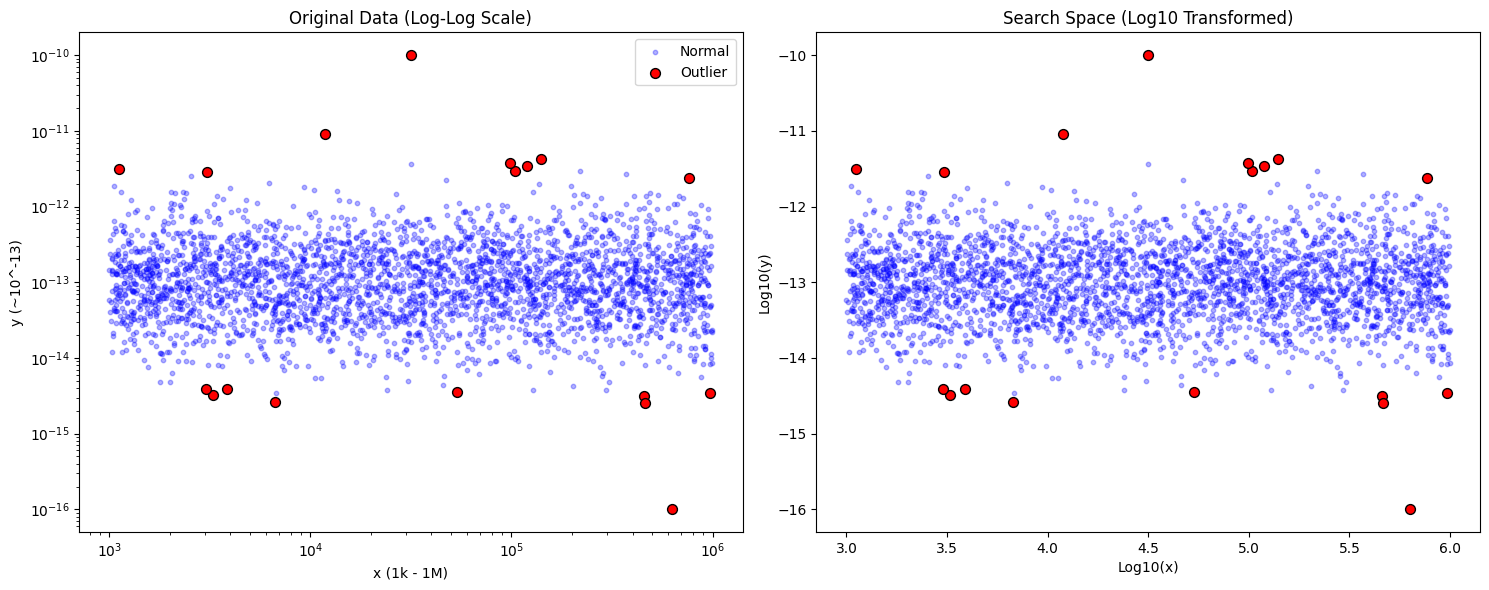

Detected 18 outliers.


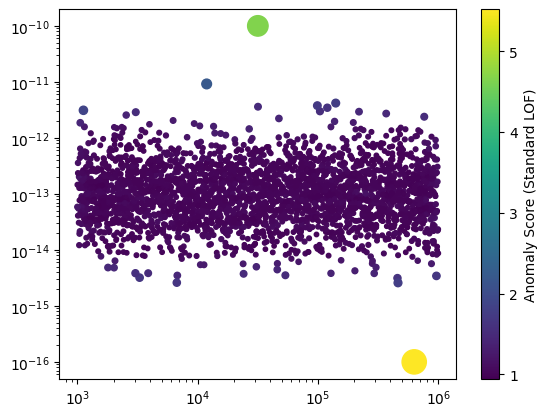

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

# 1. Setup synthetic data matching your specific scales
np.random.seed(42)
n_samples = 3000

# x: [1k, 1M], y: around 10^-13
x = 10**np.random.uniform(3, 6, n_samples)
y = 10**np.random.normal(-13, 0.5, n_samples)
data = np.column_stack([x, y])

print("Sample of original data (first 5 rows):")
print(data[:5])

# Add intentional outliers
# Outlier 1: High y value relative to its x position
# Outlier 2: Low x value but significantly different y
outliers = np.array([
    [10**4.5, 10**-10], 
    [10**5.8, 10**-16]
])
X = np.vstack([data, outliers])

def detect_outliers_optimized(data):
    """
    Optimized outlier detection for extreme scale differences.
    """
    # Step A: Log transformation
    # Converts [10^3, 10^6] -> [3, 6] and 10^-13 -> -13
    # This prevents floating point underflow/overflow in distance calculations
    X_log = np.log10(data)
    
    # Step B: Robust Scaling
    # Standardizes the data using median and IQR, making it outlier-resistant
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_log)
    print("Data after log transformation and robust scaling:")

    # Step C: Local Outlier Factor
    # k=20 is a standard starting point for datasets in the low thousands
    # contamination is the expected percentage of outliers
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
    
    # Predict: 1 for inlier, -1 for outlier
    labels = lof.fit_predict(X_scaled)
    # Negative outlier factor: higher absolute value means more 'outlying'
    scores = -lof.negative_outlier_factor_
    
    return labels == -1, X_log, scores

# Run detection
is_outlier, X_log, anomaly_scores = detect_outliers_optimized(X)

# 2. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original Scale (Log-Log Plot)
# 正常値と外れ値のデータをあらかじめ変数に切り出す
inliers = X[~is_outlier]
outliers = X[is_outlier]

# scatterには、列を分離して渡す
ax1.scatter(inliers[:, 0], inliers[:, 1], c='blue', s=10, alpha=0.3, label='Normal')
ax1.scatter(outliers[:, 0], outliers[:, 1], c='red', s=50, edgecolors='k', label='Outlier')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title("Original Data (Log-Log Scale)")
ax1.set_xlabel("x (1k - 1M)")
ax1.set_ylabel("y (~10^-13)")
ax1.legend()

# Feature Space for Algorithm (Log-transformed & Scaled)
inliers_log = X_log[~is_outlier]
outliers_log = X_log[is_outlier]

ax2.scatter(inliers_log[:, 0], inliers_log[:, 1], c='blue', s=10, alpha=0.3)
ax2.scatter(outliers_log[:, 0], outliers_log[:, 1], c='red', s=50, edgecolors='k')
ax2.set_title("Search Space (Log10 Transformed)")
ax2.set_xlabel("Log10(x)")
ax2.set_ylabel("Log10(y)")

plt.tight_layout()
plt.show()

print(f"Detected {np.sum(is_outlier)} outliers.")

# Visualize suspicion level by point size
plt.scatter(X[:, 0], X[:, 1], s=(anomaly_scores**2) * 10, c=anomaly_scores, cmap='viridis')
plt.colorbar(label='Anomaly Score (Standard LOF)')
plt.xscale('log')
plt.yscale('log')
# Bigger points = Higher anomaly score
plt.show()
